# ChromSeek TAD Prediction Workflow

This notebook loads the bundled DNA/Hi-C example, predicts TAD boundaries with the pretrained ChromSeek model, computes boundary metrics, and overlays predicted TADs on the Hi-C map.

In [1]:
# ==========================================
# 1. Configuration & Setup
# ==========================================
from pathlib import Path

for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (PROJECT_ROOT / 'hic_enhancement').is_dir() and (PROJECT_ROOT / 'downstreams').is_dir():
        break
else:
    raise FileNotFoundError('Could not locate the ChromSeek project root.')
TASK_DIR = PROJECT_ROOT / 'downstreams' / 'tad_prediction'
DATA_PATH = TASK_DIR / 'sample_data.pt'
CKPT_PATH = PROJECT_ROOT / 'checkpoints' / 'chromSeek_tad_prediction.pth'
BOUNDARY_THRESHOLD = 0.50
NMS_MAX_GAP = 50
MIN_TAD_BINS = 10

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Sample data not found: {DATA_PATH}')
if not CKPT_PATH.exists():
    raise FileNotFoundError(f'TAD checkpoint not found: {CKPT_PATH}')
print(f'Configured data: {DATA_PATH}')
print(f'Configured checkpoint: {CKPT_PATH}')
print(f'Boundary threshold: {BOUNDARY_THRESHOLD}; NMS gap: {NMS_MAX_GAP} bins')

Configured data: /home/common/qxzhang_zhuli/chromSeek/downstreams/tad_prediction/sample_data.pt
Configured checkpoint: /home/common/qxzhang_zhuli/chromSeek/checkpoints/chromSeek_tad_prediction.pth
Boundary threshold: 0.5; NMS gap: 50 bins


In [2]:
# ==========================================
# 2. Load Dependencies & Imports
# ==========================================
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

sys.path.insert(0, str(PROJECT_ROOT))
from downstreams.tad_prediction.model import DnaHicTadPredictor

cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')
print(f'Using device: {device}')
if not cuda_available:
    print('GPU is not visible to this Jupyter kernel; inference will run on CPU.')

Using device: cuda


In [3]:
# ==========================================
# 3. Load DNA, Hi-C & TAD Labels
# ==========================================
data_list = torch.load(DATA_PATH, map_location='cpu', weights_only=False)
if not isinstance(data_list, (list, tuple)) or len(data_list) == 0:
    raise ValueError('Expected sample_data.pt to contain a non-empty list of samples')
sample = data_list[0]
required = {'inputs', 'targets', 'info'}
if not required.issubset(sample):
    raise KeyError(f'Sample is missing fields: {sorted(required.difference(sample))}')
seq = sample['inputs']['seq'].float()
hic = sample['inputs']['hic'].float()
gt_tad = sample['targets']['tad'].squeeze().cpu().numpy().astype(np.int64)
raw_hic = np.asarray(sample['info']['raw_hic'])
print(f'DNA tensor: {tuple(seq.shape)}')
print(f'Hi-C tensor: {tuple(hic.shape)}')
print(f'TAD labels: {gt_tad.shape}; positive boundaries: {int(gt_tad.sum())}')
print(f'Raw Hi-C map: {raw_hic.shape}')

DNA tensor: (4, 2240000)
Hi-C tensor: (1, 224, 224)
TAD labels: (2240,); positive boundaries: 5
Raw Hi-C map: (224, 224)


In [4]:
# ==========================================
# 4. Preprocessing Data for Model
# ==========================================
t_seq = seq.unsqueeze(0) if seq.ndim == 2 else seq
t_hic = hic.unsqueeze(0) if hic.ndim == 3 else hic
t_seq = torch.nan_to_num(t_seq, nan=0.0, posinf=0.0, neginf=0.0).clamp(0, 1).to(device)
# sample_data.pt stores the same log1p/max-normalized Hi-C representation used during training.
t_hic = torch.nan_to_num(t_hic, nan=0.0, posinf=0.0, neginf=0.0).clamp_min(0).to(device)
print(f'Model DNA input: {tuple(t_seq.shape)}')
print(f'Model Hi-C input: {tuple(t_hic.shape)}')

Model DNA input: (1, 4, 2240000)
Model Hi-C input: (1, 1, 224, 224)


In [5]:
# ==========================================
# 5. Load Pretrained TAD Model
# ==========================================
print('Building TAD predictor...', flush=True)
model = DnaHicTadPredictor(pretrained_path=None).to(device)
print('Loading checkpoint...', flush=True)
state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
state_dict = {(k[7:] if k.startswith('module.') else k): v for k, v in state_dict.items()}
missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
model.eval()
print('TAD prediction model is ready.')
if missing_keys:
    print(f'Unloaded model keys: {len(missing_keys)}')
if unexpected_keys:
    print(f'Unused checkpoint keys: {len(unexpected_keys)}')

Building TAD predictor...
Loading checkpoint...
TAD prediction model is ready.


In [6]:
# ==========================================
# 6. Run TAD Inference
# ==========================================
print('Starting TAD boundary inference; this may take a moment...', flush=True)
amp_enabled = device.type == 'cuda'
with torch.inference_mode():
    with torch.autocast(device_type=device.type, enabled=amp_enabled):
        tad_logits = model(t_seq, t_hic)
    pred_prob = F.softmax(tad_logits, dim=1)[:, 1, :].squeeze().float().cpu().numpy()
print(f'TAD output shape: {pred_prob.shape}')
print(f'Boundary probability range: [{pred_prob.min():.4f}, {pred_prob.max():.4f}], mean={pred_prob.mean():.4f}')

Starting TAD boundary inference; this may take a moment...
TAD output shape: (2240,)
Boundary probability range: [0.0000, 0.9116], mean=0.0210


In [7]:
# ==========================================
# 7. Post-process Boundaries & Compute Metrics
# ==========================================
def cluster_and_nms(prob, threshold=0.5, max_gap=50):
    selected = np.where(prob >= threshold)[0]
    if selected.size == 0:
        return np.zeros(prob.shape, dtype=np.int64)
    groups, current = [], [int(selected[0])]
    for idx in selected[1:]:
        if int(idx) - current[-1] <= max_gap:
            current.append(int(idx))
        else:
            groups.append(current); current = [int(idx)]
    groups.append(current)
    result = np.zeros(prob.shape, dtype=np.int64)
    for group in groups:
        result[group[int(np.argmax(prob[group]))]] = 1
    return result

pred_boundary = cluster_and_nms(pred_prob, BOUNDARY_THRESHOLD, NMS_MAX_GAP)
precision = precision_score(gt_tad, pred_boundary, zero_division=0)
recall = recall_score(gt_tad, pred_boundary, zero_division=0)
f1_value = f1_score(gt_tad, pred_boundary, zero_division=0)
ap_value = average_precision_score(gt_tad, pred_prob) if np.unique(gt_tad).size > 1 else 0.0
print(f'Predicted boundary count after NMS: {int(pred_boundary.sum())}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 @ {BOUNDARY_THRESHOLD:.2f}: {f1_value:.4f}')
print(f'Average precision: {ap_value:.4f}')

Predicted boundary count after NMS: 5
Precision: 0.4000
Recall: 0.4000
F1 @ 0.50: 0.4000
Average precision: 0.2928


In [8]:
# ==========================================
# 8. Convert Boundaries to TAD Intervals
# ==========================================
def boundaries_to_tads(boundaries, min_bins=10, total_bins=2240):
    points = sorted(set([0, total_bins - 1]) | set(np.asarray(boundaries, dtype=int).tolist()))
    return [(start / 10.0, end / 10.0) for start, end in zip(points[:-1], points[1:]) if end - start >= min_bins]

true_tads = boundaries_to_tads(np.where(gt_tad == 1)[0], MIN_TAD_BINS, len(gt_tad))
pred_tads = boundaries_to_tads(np.where(pred_boundary == 1)[0], MIN_TAD_BINS, len(pred_boundary))
print(f'Ground-truth TAD intervals: {len(true_tads)}')
print(f'Predicted TAD intervals: {len(pred_tads)}')

Ground-truth TAD intervals: 6
Predicted TAD intervals: 6


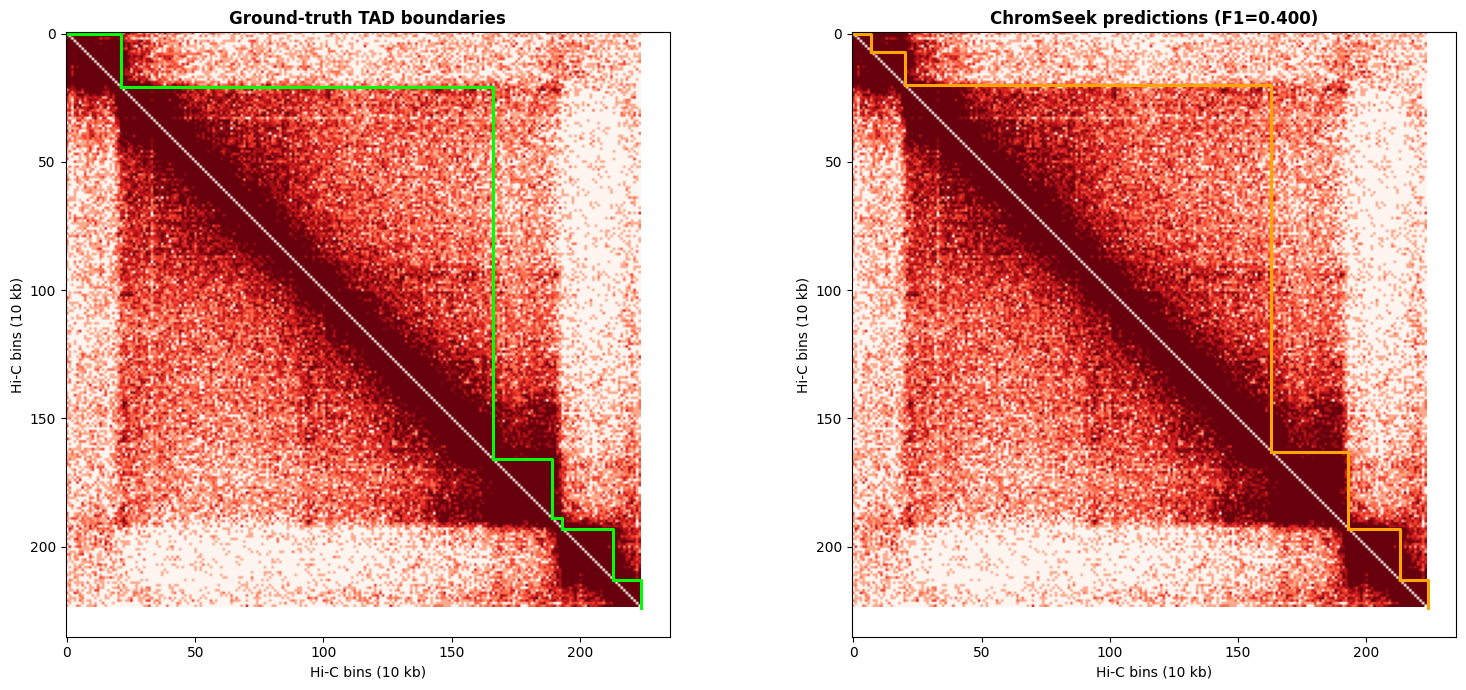

Workflow complete. Adjust BOUNDARY_THRESHOLD and rerun cells 7-9 to inspect another operating point.


In [9]:
# ==========================================
# 9. Visualize TADs on Hi-C
# ==========================================
def plot_tads(ax, matrix, tads, title, color):
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0).clip(min=0)
    logged = np.log1p(matrix)
    positive = logged[logged > 0]
    vmax = np.percentile(positive, 80) if positive.size else 1.0
    ax.imshow(logged, cmap='Reds', vmin=0, vmax=max(vmax, 1e-6), origin='upper')
    for start, end in tads:
        ax.plot([start, end, end], [start, start, end], color=color, linewidth=2.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Hi-C bins (10 kb)')
    ax.set_ylabel('Hi-C bins (10 kb)')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_tads(axes[0], raw_hic, true_tads, 'Ground-truth TAD boundaries', 'lime')
plot_tads(axes[1], raw_hic, pred_tads, f'ChromSeek predictions (F1={f1_value:.3f})', 'orange')
plt.tight_layout()
plt.show()
print('Workflow complete. Adjust BOUNDARY_THRESHOLD and rerun cells 7-9 to inspect another operating point.')